# 04 — Evaluation

## Dependencies
- Requires: `../results/predictions.pkl` (run 03_models first)
- Produces: Calibration plots, comparison table, win probability plots

# Library Imports

In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [3]:
import sys
sys.path.append('..')
from src.metrics import ranked_probability_score, multiclass_brier_score, ece, print_ece
from src.viz import plot_calibration, plot_combined_win_probability_with_goals

In [4]:
with open('../results/predictions.pkl', 'rb') as f:
    results = pickle.load(f)

probs             = results['probs_lstm']
probs_gru         = results['probs_gru']
outcomes          = results['outcomes']
y_pred_goals      = results['y_pred_goals']
y_pred_goals_gru  = results['y_pred_goals_gru']
y_true_goals      = results['y_true_goals']
test_rows         = results['test_rows']
mae_goals         = results['mae_goals']
mae_gru           = results['mae_gru']
rps_lstm          = results['rps_lstm']
rps_gru           = results['rps_gru']
brier_lstm        = results['brier_lstm']
brier_gru         = results['brier_gru']
baseline_mae      = results['baseline_mae']
baseline_rps      = results['baseline_rps']
baseline_brier    = results['baseline_brier']

print("All results loaded successfully.")

All results loaded successfully.


# Model evaluation

In [62]:
# Model Performance Metrics (MAE, Brier Score, RPS) 

print('=' * 52)
print(f'{"Metric":<25} {"Baseline":>8} {"LSTM":>8} {"GRU":>8}')
print('=' * 52)
print(f'{"Remaining-goals MAE":<25} {baseline_mae:>8.4f} {mae_goals:>8.4f} {mae_gru:>8.4f}')
print(f'{"RPS (lower=better)":<25} {baseline_rps:>8.4f} {rps_lstm:>8.4f} {rps_gru:>8.4f}')
print(f'{"Multiclass Brier":<25} {baseline_brier:>8.4f} {brier_lstm:>8.4f} {brier_gru:>8.4f}')
print('=' * 52)

Metric                    Baseline     LSTM      GRU
Remaining-goals MAE         0.7677   0.6593   0.6550
RPS (lower=better)          0.1377   0.1074   0.1060
Multiclass Brier            0.4488   0.3582   0.3548


- Both models outperform baseline across all three metrics (MAE, RPS, Brier), indicating meaningful improvement in goal prediction and match outcome probability.
- LSTM and GRU show comparable performance with no clear winner between them.
 

In [60]:
# Discrimination ratios — home and away remaining goals

def discrimination_ratio(y_true, y_pred):
    pos = y_pred[y_true > 0]
    zero = y_pred[y_true == 0]
    return pos.mean() / zero.mean()

print("LSTM Home Goals DR :", round(discrimination_ratio(y_true_goals[:,0], y_pred_goals[:,0]),3))
print("LSTM Away Goals DR :", round(discrimination_ratio(y_true_goals[:,1], y_pred_goals[:,1]),3))

print("GRU Home Goals DR  :", round(discrimination_ratio(y_true_goals[:,0], y_pred_goals_gru[:,0]),3))
print("GRU Away Goals DR  :", round(discrimination_ratio(y_true_goals[:,1], y_pred_goals_gru[:,1]),3))

LSTM Home Goals DR : 2.247
LSTM Away Goals DR : 1.798
GRU Home Goals DR  : 2.222
GRU Away Goals DR  : 1.807


- Discrimination ratios above 2.0 indicate strong separation between matches with and without goals.
- Models assign systematically higher predictions when goals actually occur.

In [90]:
# Expected Calibration Error
print_ece(probs, outcomes, model_name='LSTM')
print_ece(probs_gru, outcomes, model_name='GRU')

LSTM — Expected Calibration Error (lower is better)
  Home win  : ECE = 0.0429
  Draw      : ECE = 0.0421
  Away win  : ECE = 0.0226
GRU — Expected Calibration Error (lower is better)
  Home win  : ECE = 0.0330
  Draw      : ECE = 0.0410
  Away win  : ECE = 0.0332


- Both models show strong overall calibration with all ECE values below 0.05, meaning predicted probabilities closely reflect real outcome frequencies across home wins, draws, and away wins.
- GRU is better calibrated for home win predictions, while LSTM has a clear edge on away win calibration — suggesting each model has outcome-specific strengths rather than one being uniformly superior.
- Draw predictions are similarly calibrated across both models, reflecting the inherent difficulty of predicting draws as neither model captures that outcome particularly well.

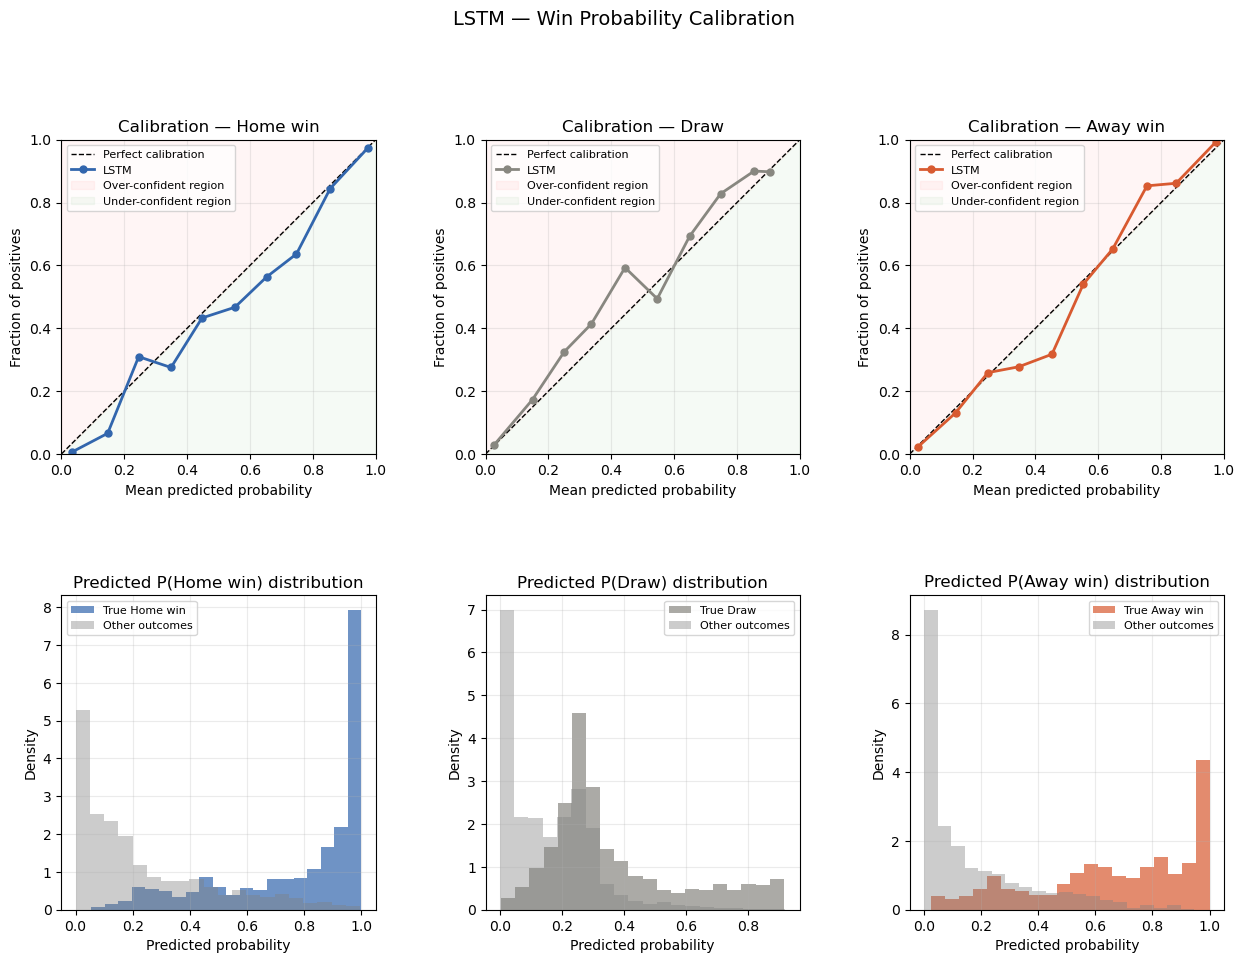

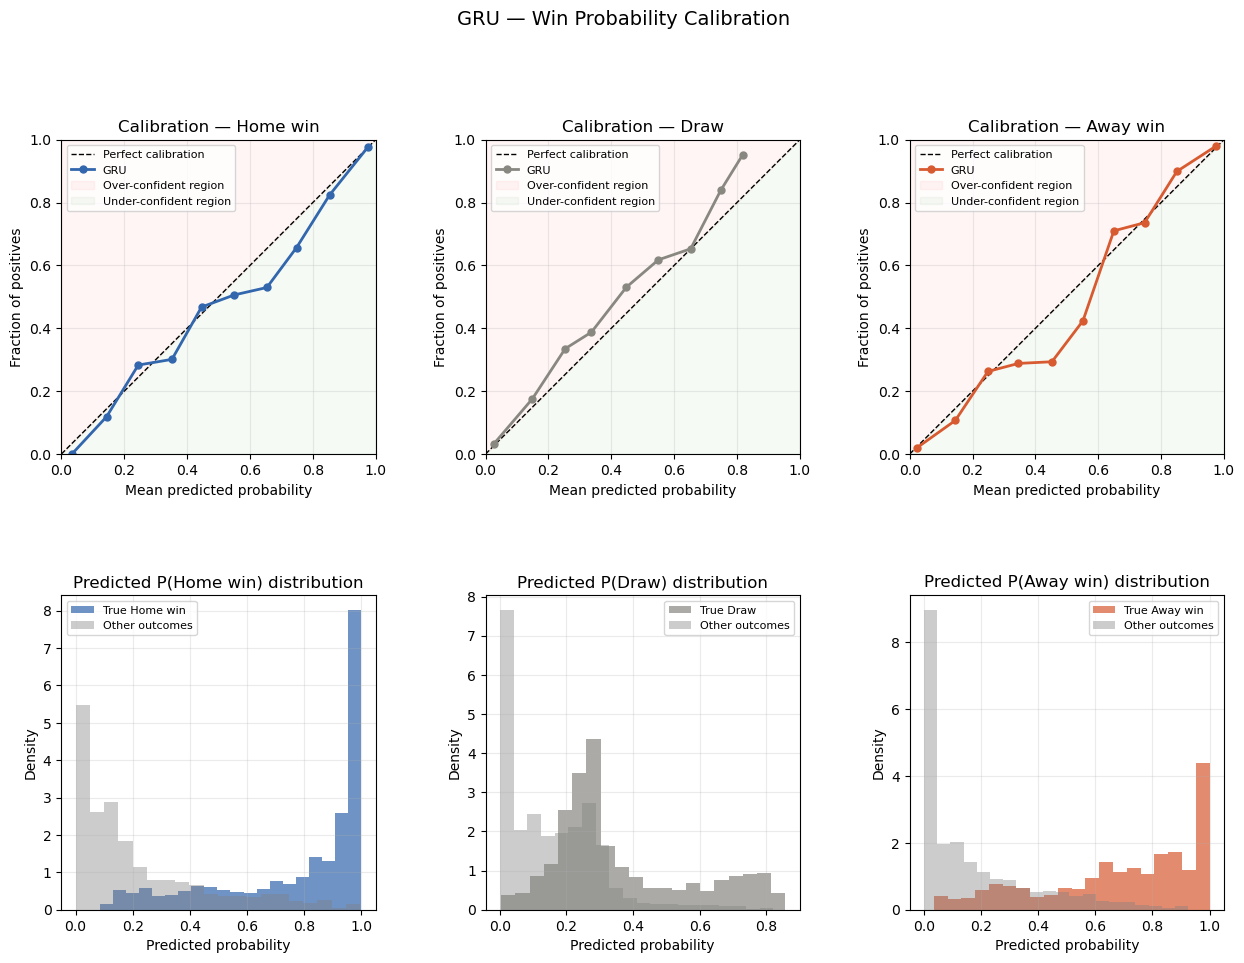

In [56]:
# Calibration plot
plot_calibration(probs, outcomes, model_name='LSTM')
plot_calibration(probs_gru, outcomes, model_name='GRU')

- Diagonal alignment in both plots indicates well-calibrated predictions—predicted 60% correlates with ~60% actual occurrence.
- Minor deviations are expected and don't suggest systematic bias.

In [78]:
# Find matches with goals in both halves

interesting_matches = (
    test_rows.groupby('match_id')
    .agg(home_goals=('future_home_goals', 'first'),
         away_goals=('future_away_goals', 'first'))
    .query('home_goals > 0 and away_goals > 0')
    .index.tolist()
)

sample_match_id = interesting_matches[0]
print(f"Plotting match: {sample_match_id}")

Plotting match: 9602


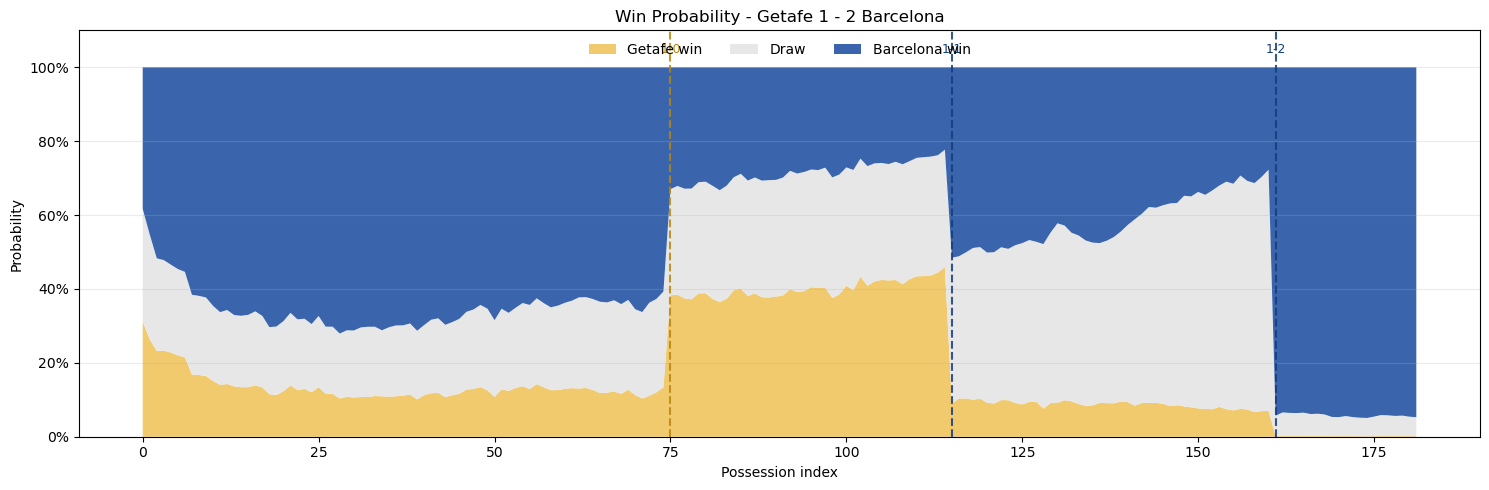

In [94]:
# Win Probability graph - LSTM

plot_combined_win_probability_with_goals(
    match_id  = sample_match_id,
    test_rows = test_rows,
    probs     = probs
)

- LSTM-predicted win probabilities and remaining goal counts evolve realistically through the match.
- Sharp shifts indicate the model responds to match events captured in the sequence.

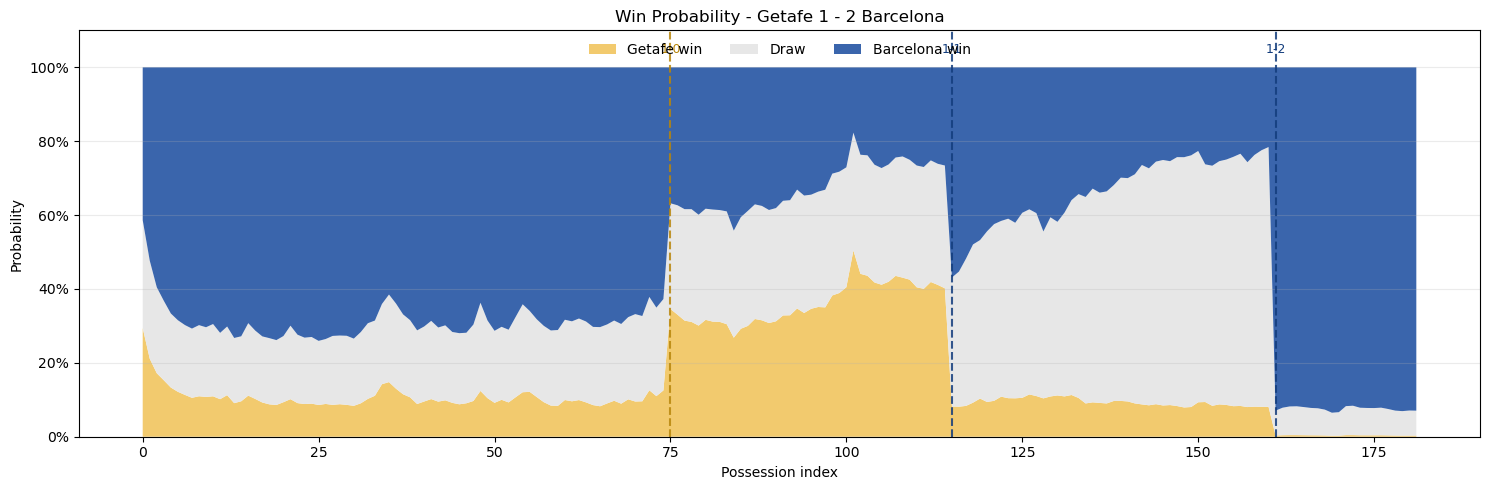

In [96]:
# Win Probability Graph - GRU

plot_combined_win_probability_with_goals(
    match_id   = sample_match_id,
    test_rows  = test_rows,
    probs      = probs_gru
)

- GRU predictions are more responsive to in-game dynamics than LSTM, with visible spikes between goals suggesting the model captures non-goal events such as shifts in possession or attacking pressure.
- This increased reactivity may reflect GRU's simpler gating mechanism, which is more sensitive to short-term sequence changes compared to LSTM's longer memory.

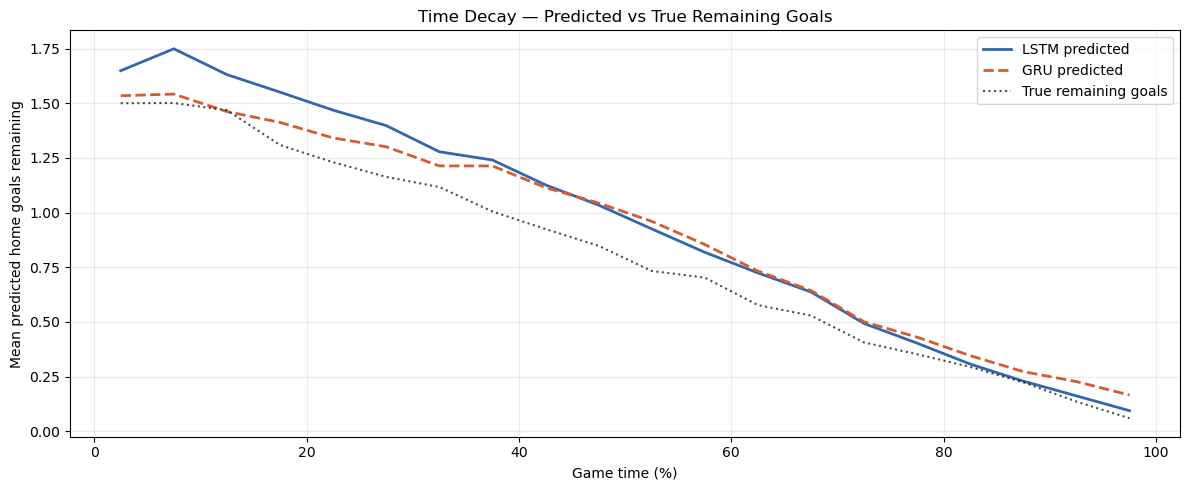

── Time decay summary ─────────────────────────────────
LSTM | early: 1.5697 | late: 0.1782
GRU  | early: 1.4306 | late: 0.2361
True | early: 1.3700 | late: 0.1556


In [99]:
# Time decay plot

test_rows_reset = test_rows.reset_index(drop=True)

early_pos = test_rows_reset[test_rows_reset['game_time_pct'] < 30].index
late_pos  = test_rows_reset[test_rows_reset['game_time_pct'] > 80].index

bins = np.linspace(0,100,21)
labels = (bins[:-1] + bins[1:]) / 2

test_rows_reset['time_bin'] = pd.cut(test_rows_reset['game_time_pct'], bins=bins, labels=labels).astype(float)

lstm = test_rows_reset.assign(pred=y_pred_goals[:len(test_rows_reset),0]).groupby('time_bin')['pred'].mean()
gru  = test_rows_reset.assign(pred=y_pred_goals_gru[:len(test_rows_reset),0]).groupby('time_bin')['pred'].mean()
true = test_rows_reset.groupby('time_bin')['future_home_goals'].mean()

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(lstm.index, lstm.values, color='#3266ad', lw=2, label='LSTM predicted')
ax.plot(gru.index, gru.values, color='#D85A30', lw=2, ls='--', label='GRU predicted')
ax.plot(true.index, true.values, color='black', lw=1.5, ls=':', alpha=0.7, label='True remaining goals')

ax.set_xlabel('Game time (%)')
ax.set_ylabel('Mean predicted home goals remaining')
ax.set_title('Time Decay — Predicted vs True Remaining Goals')
ax.legend(fontsize=10)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('../results/time_decay.png', dpi=150, bbox_inches='tight')
plt.show()

print('── Time decay summary ─────────────────────────────────')
print(f'LSTM | early: {y_pred_goals[early_pos,0].mean():.4f} | late: {y_pred_goals[late_pos,0].mean():.4f}')
print(f'GRU  | early: {y_pred_goals_gru[early_pos,0].mean():.4f} | late: {y_pred_goals_gru[late_pos,0].mean():.4f}')
print(f'True | early: {test_rows_reset.iloc[early_pos]["future_home_goals"].mean():.4f} | late: {test_rows_reset.iloc[late_pos]["future_home_goals"].mean():.4f}')

- Both models decay realistically as match time increases, closely tracking actual remaining goals throughout the match and confirming genuine time-dependent learning.
- However, both models show slight overconfidence in the early stages, predicting marginally more goals than actually occur before enough match context has accumulated.

# Final Evaluation and Model Comparison

The results demonstrate clear performance advantages of sequence-based architectures and the effectiveness of temporal modeling for match outcome prediction across 793 La Liga matches.

## Summary of Key Observations

* **Architecture Superiority:** Both LSTM and GRU models consistently outperformed the baseline across all three metrics — MAE, RPS, and Brier score. This confirms that architectures specifically designed for sequential data capture temporal patterns in match events that a static baseline simply cannot.

* **Strong Goal Discrimination:** Both models achieved discrimination ratios above 2.0 for home goals and above 1.7 for away goals, showing they assign meaningfully higher predictions when goals actually occur. Home goals were discriminated more strongly than away goals by both models, reflecting the well-known home advantage signal in the data.

* **Outcome-Specific Calibration:** Both models show strong overall calibration with all ECE values below 0.05, confirming predicted probabilities are reliable across all three outcomes. However, GRU is better calibrated for home win predictions while LSTM leads on away win calibration — suggesting each model has outcome-specific strengths rather than one being uniformly superior. Draw predictions are similarly calibrated across both models, reflecting the inherent difficulty of predicting draws reliably.

* **Smooth vs Reactive Win Probabilities:** The LSTM produces smoother win probability curves, prioritising long-term match trends and filtering out short-term fluctuations — making it better suited for final outcome prediction. The GRU is more responsive to in-game dynamics, with visible probability spikes between goals reflecting real-time shifts in possession and attacking pressure — making it better suited for live match tracking where capturing momentum shifts matters.

* **Realistic Time Decay with Early Overconfidence:** Both models decay realistically as match time increases, closely tracking actual remaining goals throughout the match and confirming genuine time-dependent learning. However, both show slight overconfidence in the early stages — predicting marginally more goals than actually occur before enough match context has accumulated — which is a known limitation when sequence models have limited input to work with.

## Conclusion

The experiments clearly show that sequence-based deep learning models provide a significant and reliable advantage in match outcome and goal prediction compared to traditional baselines. Both LSTM and GRU architectures achieved strong, well-calibrated predictions that adapt realistically to match progression, validating the use of possession-level sequential features enriched with Elo ratings and xG. The choice between them depends on the application — LSTM's stability makes it more reliable for pre-match or full-time outcome prediction, while GRU's responsiveness to in-game events makes it better suited for live match tracking. A shared limitation of both models is early-stage overconfidence, where predictions are less reliable before sufficient match context has accumulated, which presents a clear direction for future work in confidence calibration at early timesteps.